# [HMS Project Code-1] Overview Data 크롤링하기

In [ ]:
import time
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup

BASE_LIST_URL = "https://host.cine21.com/movie/lists/playing/"
HEADERS = {
    "User-Agent": "Mozilla/5.0",
}
REQUEST_TIMEOUT = 10
REQUEST_DELAY = 0.3


def fetch_html(url, params=None):
    response = requests.get(url, headers=HEADERS, params=params, timeout=REQUEST_TIMEOUT)
    response.raise_for_status()
    return response.text


def clean_title(text):
    if not text:
        return None
    t = re.sub(r"\s+", " ", str(text)).strip()
    for kw in ["개봉", "감독", "배우", "자세히 보기"]:
        idx = t.find(kw)
        if idx != -1:
            t = t[:idx]
            break
    return t.strip()


def extract_movies_from_soup(soup):
    rows = []
    seen_ids = set()
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if "movie_id=" not in href:
            continue
        match = re.search(r"movie_id=(\d+)", href)
        if not match:
            continue
        movie_id = int(match.group(1))
        if movie_id in seen_ids:
            continue
        seen_ids.add(movie_id)
        raw = a.get_text(" ", strip=True)
        title = clean_title(raw)
        if not title:
            continue
        rows.append(
            {
                "movie_id": movie_id,
                "title": title,
            }
        )
    return rows


def fetch_list_page(page=1):
    html = fetch_html(BASE_LIST_URL, params={"p": page})
    soup = BeautifulSoup(html, "html.parser")
    return extract_movies_from_soup(soup)


def crawl_overview_data(max_pages=100, max_movies=None):
    all_rows = []
    seen_global = set()
    rank = 0

    for page in range(1, max_pages + 1):
        rows = fetch_list_page(page=page)
        if not rows:
            break

        new_rows = []
        for row in rows:
            movie_id = row["movie_id"]
            if movie_id in seen_global:
                continue
            seen_global.add(movie_id)
            rank += 1
            row["rank"] = rank
            new_rows.append(row)

            if max_movies is not None and rank >= max_movies:
                all_rows.extend(new_rows)
                return pd.DataFrame(all_rows)

        if not new_rows:
            break

        all_rows.extend(new_rows)
        time.sleep(REQUEST_DELAY)

    return pd.DataFrame(all_rows)


overview_df = crawl_overview_data(max_pages=10, max_movies=1000)
overview_df.head()




,movie_id,title,rank
0,8089,석류의 빛깔,1
1,60010,동에 번쩍 서에 번쩍,2
2,62383,주토피아 2,3
3,62775,힘,4
4,62696,극장판 나와 로보코,5


# [HMS Project Code-2] Detailed Data 크롤링하기

In [ ]:
import time
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup

BASE_INFO_URL = "https://cine21.com/movie/info/"
HEADERS = {
    "User-Agent": "Mozilla/5.0",
}
REQUEST_TIMEOUT = 10
REQUEST_DELAY = 0.3


def fetch_html(url, params=None):
    response = requests.get(url, headers=HEADERS, params=params, timeout=REQUEST_TIMEOUT)
    response.raise_for_status()
    return response.text


def to_int(text):
    if text is None:
        return None
    s = re.sub(r"[^0-9]", "", str(text))
    return int(s) if s else None


def to_float(text):
    if text is None:
        return None
    s = str(text).strip()
    try:
        return float(s)
    except ValueError:
        s = s.replace(",", "")
        try:
            return float(s)
        except ValueError:
            return None


def parse_movie_info_html(html):
    soup = BeautifulSoup(html, "html.parser")

    info_block = soup.find("div", class_="movie_detail_info")
    if info_block is None:
        info_block = soup

    title_ko = None
    title_en = None
    year = None

    title_block = info_block.find("div", class_="movie_title")
    if title_block:
        paragraphs = title_block.find_all("p", recursive=False)
        if paragraphs:
            first = paragraphs[0]
            title_ko = first.get_text(strip=True) if first else None
        for p in paragraphs:
            classes = p.get("class") or []
            if "eng" in classes:
                txt = " ".join(p.stripped_strings)
                match = re.search(r"(.*)\((\d{4})\)", txt)
                if match:
                    title_en = match.group(1).strip()
                    year = to_int(match.group(2))
                else:
                    title_en = txt
                break

    open_date = None
    rating = None
    runtime_min = None
    audience_total = None
    genres = None
    country = None
    directors = []
    cast = []

    info_list = info_block.find("ul", class_="info_list")
    if info_list:
        li_list = info_list.find_all("li", recursive=False)
    else:
        li_list = info_block.find_all("li")

    for li in li_list:
        label_tag = li.find("p", class_="title")
        if not label_tag:
            continue
        label = label_tag.get_text(strip=True)
        parts = list(li.stripped_strings)
        if not parts:
            continue
        if parts[0] == label:
            parts = parts[1:]
        value_text = " ".join(parts).strip()

        if label == "개봉" and not open_date:
            open_date = value_text
        elif label == "등급":
            rating = value_text
        elif label == "시간":
            runtime_min = to_int(value_text)
        elif label == "관객":
            audience_total = to_int(value_text)
        elif label == "장르":
            genre_parts = [p.strip() for p in re.split(r"[,/]", value_text) if p.strip()]
            genres = genre_parts
        elif label == "국가":
            country = value_text
        elif label == "감독":
            directors = [a.get_text(strip=True) for a in li.find_all("a")]
        elif label == "출연":
            cast = [a.get_text(strip=True) for a in li.find_all("a")]

        cine21_score = None
        netizen_score = None

        text_all = soup.get_text(" ", strip=True)

        m1 = re.search(r"씨네21 전문가 별점\s*([0-9]+(?:\.[0-9]+)?)", text_all)
        if m1:
            cine21_score = to_float(m1.group(1))

        m2 = re.search(r"관객 별점\s*([0-9]+(?:\.[0-9]+)?)", text_all)
        if m2:
            netizen_score = to_float(m2.group(1))

    return {
        "title_ko": title_ko,
        "title_en": title_en,
        "year": year,
        "open_date_detail": open_date,
        "rating": rating,
        "runtime_min": runtime_min,
        "audience_total": audience_total,
        "genres": ", ".join(genres) if genres else None,
        "country": country,
        "directors": ", ".join(directors) if directors else None,
        "num_directors": len(directors),
        "cast_main": ", ".join(cast) if cast else None,
        "num_cast_main": len(cast),
        "cine21_score_detail": cine21_score,
        "netizen_score": netizen_score,
    }


def fetch_movie_info(movie_id, delay=REQUEST_DELAY):
    html = fetch_html(BASE_INFO_URL, params={"movie_id": movie_id})
    data = parse_movie_info_html(html)
    data["movie_id"] = movie_id
    time.sleep(delay)
    return data


def crawl_detailed_data(movie_ids, delay=REQUEST_DELAY):
    details = []
    total = len(movie_ids)
    for i, movie_id in enumerate(movie_ids, start=1):
        print(f"[{i}/{total}] movie_id={movie_id} 크롤링 중...")
        try:
            detail = fetch_movie_info(movie_id, delay=delay)
            details.append(detail)
        except Exception as exc:
            print("detail error", movie_id, exc)
    if not details:
        return pd.DataFrame()
    return pd.DataFrame(details)


movie_ids = (
    overview_df["movie_id"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

detail_df = crawl_detailed_data(movie_ids, delay=REQUEST_DELAY)
detail_df.head()


[1/150] movie_id=8089 크롤링 중...
[2/150] movie_id=60010 크롤링 중...
[3/150] movie_id=62383 크롤링 중...
[4/150] movie_id=62775 크롤링 중...
[5/150] movie_id=62696 크롤링 중...
[6/150] movie_id=62698 크롤링 중...
[7/150] movie_id=62699 크롤링 중...
[8/150] movie_id=62705 크롤링 중...
[9/150] movie_id=62710 크롤링 중...
[10/150] movie_id=62734 크롤링 중...
[11/150] movie_id=62758 크롤링 중...
[12/150] movie_id=62762 크롤링 중...
[13/150] movie_id=10302 크롤링 중...
[14/150] movie_id=62678 크롤링 중...
[15/150] movie_id=62781 크롤링 중...
[16/150] movie_id=62195 크롤링 중...
[17/150] movie_id=62531 크롤링 중...
[18/150] movie_id=62716 크롤링 중...
[19/150] movie_id=62356 크롤링 중...
[20/150] movie_id=62582 크롤링 중...
[21/150] movie_id=62759 크롤링 중...
[22/150] movie_id=62760 크롤링 중...
[23/150] movie_id=62782 크롤링 중...
[24/150] movie_id=62661 크롤링 중...
[25/150] movie_id=62594 크롤링 중...
[26/150] movie_id=62645 크롤링 중...
[27/150] movie_id=62658 크롤링 중...
[28/150] movie_id=62695 크롤링 중...
[29/150] movie_id=62680 크롤링 중...
[30/150] movie_id=62686 크롤링 중...
[31/150] movie_id=62

,title_ko,title_en,year,open_date_detail,rating,runtime_min,audience_total,genres,country,directors,num_directors,cast_main,num_cast_main,cine21_score_detail,netizen_score,movie_id
0,석류의 빛깔,,1968,2025-11-26,12세이상관람가,79.0,NaN,드라마,"러시아,아르메니아",세르게이 파라자노프,1,"소피코 치아우레리, 지오르지 제제츠코리, 스파르탁 바가쉬빌리",3,7.75,NaN,8089
1,동에 번쩍 서에 번쩍,,2022,2025-11-26,12세이상관람가,101.0,186.0,어드벤처,한국,이광국,1,"여설희, 우화정, 서지안",3,5.67,NaN,60010
2,주토피아 2,,2025,2025-11-26,전체 관람가,108.0,1783.0,애니메이션,미국,"재러드 부시, 바이론 하워드",2,"지니퍼 굿윈, 제이슨 베이트먼, 키 호이 콴",3,NaN,NaN,62383
3,힘,,2025,2025-11-26,청소년 관람불가,96.0,NaN,"스포츠, 공포",미국,저스틴 팁핑,1,"타이릭 위더스, 말론 웨이언스",2,NaN,NaN,62775
4,극장판 나와 로보코,,2025,2025-11-26,12세이상관람가,64.0,NaN,"코미디, 애니메이션",일본,다이치 아키타로,1,None,0,NaN,NaN,62696


# [HMS Project Code-3] 데이터 병합하기

In [ ]:
import pandas as pd

total_df = overview_df.merge(detail_df, on="movie_id", how="left")
total_df.to_csv("hms_movies.csv", index=False, encoding="utf-8-sig")
total_df.head()


,movie_id,title,rank,title_ko,title_en,year,open_date_detail,rating,runtime_min,audience_total,genres,country,directors,num_directors,cast_main,num_cast_main,cine21_score_detail,netizen_score
0,8089,석류의 빛깔,1,석류의 빛깔,,1968,2025-11-26,12세이상관람가,79.0,NaN,드라마,"러시아,아르메니아",세르게이 파라자노프,1,"소피코 치아우레리, 지오르지 제제츠코리, 스파르탁 바가쉬빌리",3,7.75,NaN
1,60010,동에 번쩍 서에 번쩍,2,동에 번쩍 서에 번쩍,,2022,2025-11-26,12세이상관람가,101.0,186.0,어드벤처,한국,이광국,1,"여설희, 우화정, 서지안",3,5.67,NaN
2,62383,주토피아 2,3,주토피아 2,,2025,2025-11-26,전체 관람가,108.0,1783.0,애니메이션,미국,"재러드 부시, 바이론 하워드",2,"지니퍼 굿윈, 제이슨 베이트먼, 키 호이 콴",3,NaN,NaN
3,62775,힘,4,힘,,2025,2025-11-26,청소년 관람불가,96.0,NaN,"스포츠, 공포",미국,저스틴 팁핑,1,"타이릭 위더스, 말론 웨이언스",2,NaN,NaN
4,62696,극장판 나와 로보코,5,극장판 나와 로보코,,2025,2025-11-26,12세이상관람가,64.0,NaN,"코미디, 애니메이션",일본,다이치 아키타로,1,None,0,NaN,NaN


# [HMS Project Code-4] 결측값 처리하기

In [ ]:
import pandas as pd

df_raw = pd.read_csv("hms_movies.csv")

df_na = df_raw.copy()
df_na = df_na.drop(columns=["title_en"])

df_na["rating"] = df_na["rating"].fillna("정보없음")
df_na["country"] = df_na["country"].fillna("정보없음")
df_na["directors"] = df_na["directors"].fillna("정보없음")
df_na["cast_main"] = df_na["cast_main"].fillna("정보없음")

df_na["runtime_min"] = df_na["runtime_min"].fillna(df_na["runtime_min"].median())
df_na["audience_total"] = df_na["audience_total"].fillna(df_na["audience_total"].median())

df_na["cine21_score_detail"] = df_na["cine21_score_detail"].fillna(df_na["cine21_score_detail"].mean())
df_na["netizen_score"] = df_na["netizen_score"].fillna(df_na["netizen_score"].mean())

print(df_raw.isna().sum())
print()
print(df_na.isna().sum())

df_na.head()

movie_id                 0
title                    0
rank                     0
title_ko                 0
title_en               150
year                     0
open_date_detail         0
rating                   5
runtime_min              1
audience_total          17
genres                   0
country                  3
directors                5
num_directors            0
cast_main               14
num_cast_main            0
cine21_score_detail     49
netizen_score          106
dtype: int64

movie_id               0
title                  0
rank                   0
title_ko               0
year                   0
open_date_detail       0
rating                 0
runtime_min            0
audience_total         0
genres                 0
country                0
directors              0
num_directors          0
cast_main              0
num_cast_main          0
cine21_score_detail    0
netizen_score          0
dtype: int64


,movie_id,title,rank,title_ko,year,open_date_detail,rating,runtime_min,audience_total,genres,country,directors,num_directors,cast_main,num_cast_main,cine21_score_detail,netizen_score
0,8089,석류의 빛깔,1,석류의 빛깔,1968,2025-11-26,12세이상관람가,79.0,8599.0,드라마,"러시아,아르메니아",세르게이 파라자노프,1,"소피코 치아우레리, 지오르지 제제츠코리, 스파르탁 바가쉬빌리",3,7.750000,7.398409
1,60010,동에 번쩍 서에 번쩍,2,동에 번쩍 서에 번쩍,2022,2025-11-26,12세이상관람가,101.0,186.0,어드벤처,한국,이광국,1,"여설희, 우화정, 서지안",3,5.670000,7.398409
2,62383,주토피아 2,3,주토피아 2,2025,2025-11-26,전체 관람가,108.0,1783.0,애니메이션,미국,"재러드 부시, 바이론 하워드",2,"지니퍼 굿윈, 제이슨 베이트먼, 키 호이 콴",3,6.010891,7.398409
3,62775,힘,4,힘,2025,2025-11-26,청소년 관람불가,96.0,8599.0,"스포츠, 공포",미국,저스틴 팁핑,1,"타이릭 위더스, 말론 웨이언스",2,6.010891,7.398409
4,62696,극장판 나와 로보코,5,극장판 나와 로보코,2025,2025-11-26,12세이상관람가,64.0,8599.0,"코미디, 애니메이션",일본,다이치 아키타로,1,정보없음,0,6.010891,7.398409


# [HMS Project Code-5] 이상치 처리하기

In [ ]:
import pandas as pd

df_na = pd.read_csv("hms_movies.csv")
df_na = df_na.drop(columns=["title_en"])
df_na["rating"] = df_na["rating"].fillna("정보없음")
df_na["country"] = df_na["country"].fillna("정보없음")
df_na["directors"] = df_na["directors"].fillna("정보없음")
df_na["cast_main"] = df_na["cast_main"].fillna("정보없음")
df_na["runtime_min"] = df_na["runtime_min"].fillna(df_na["runtime_min"].median())
df_na["audience_total"] = df_na["audience_total"].fillna(df_na["audience_total"].median())
df_na["cine21_score_detail"] = df_na["cine21_score_detail"].fillna(df_na["cine21_score_detail"].mean())
df_na["netizen_score"] = df_na["netizen_score"].fillna(df_na["netizen_score"].mean())

def clip_outliers(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return s.clip(lower=low, upper=high)

df_out = df_na.copy()
for col in ["runtime_min", "audience_total", "cine21_score_detail", "netizen_score"]:
    df_out[col] = clip_outliers(df_out[col])

print(df_na[["runtime_min", "audience_total"]].describe())
print()
print(df_out[["runtime_min", "audience_total"]].describe())

df_out.head()


       runtime_min  audience_total
count   150.000000    1.500000e+02
mean    102.693333    1.574512e+05
std      24.127721    6.272992e+05
min      27.000000    2.400000e+01
25%      90.000000    1.701250e+03
50%     104.000000    8.599000e+03
75%     116.750000    3.303550e+04
max     178.000000    5.650249e+06

       runtime_min  audience_total
count   150.000000      150.000000
mean    102.720833    22545.875000
std      22.501889    28447.255527
min      49.875000       24.000000
25%      90.000000     1701.250000
50%     104.000000     8599.000000
75%     116.750000    33035.500000
max     156.875000    80036.875000


,movie_id,title,rank,title_ko,year,open_date_detail,rating,runtime_min,audience_total,genres,country,directors,num_directors,cast_main,num_cast_main,cine21_score_detail,netizen_score
0,8089,석류의 빛깔,1,석류의 빛깔,1968,2025-11-26,12세이상관람가,79.0,8599.0,드라마,"러시아,아르메니아",세르게이 파라자노프,1,"소피코 치아우레리, 지오르지 제제츠코리, 스파르탁 바가쉬빌리",3,7.250000,7.398409
1,60010,동에 번쩍 서에 번쩍,2,동에 번쩍 서에 번쩍,2022,2025-11-26,12세이상관람가,101.0,186.0,어드벤처,한국,이광국,1,"여설희, 우화정, 서지안",3,5.670000,7.398409
2,62383,주토피아 2,3,주토피아 2,2025,2025-11-26,전체 관람가,108.0,1783.0,애니메이션,미국,"재러드 부시, 바이론 하워드",2,"지니퍼 굿윈, 제이슨 베이트먼, 키 호이 콴",3,6.010891,7.398409
3,62775,힘,4,힘,2025,2025-11-26,청소년 관람불가,96.0,8599.0,"스포츠, 공포",미국,저스틴 팁핑,1,"타이릭 위더스, 말론 웨이언스",2,6.010891,7.398409
4,62696,극장판 나와 로보코,5,극장판 나와 로보코,2025,2025-11-26,12세이상관람가,64.0,8599.0,"코미디, 애니메이션",일본,다이치 아키타로,1,정보없음,0,6.010891,7.398409


# [HMS Project Code-6] 중복 데이터 제거하기

In [ ]:
import pandas as pd

df_out = pd.read_csv("hms_movies.csv")
df_out = df_out.drop(columns=["title_en"])
df_out["rating"] = df_out["rating"].fillna("정보없음")
df_out["country"] = df_out["country"].fillna("정보없음")
df_out["directors"] = df_out["directors"].fillna("정보없음")
df_out["cast_main"] = df_out["cast_main"].fillna("정보없음")
df_out["runtime_min"] = df_out["runtime_min"].fillna(df_out["runtime_min"].median())
df_out["audience_total"] = df_out["audience_total"].fillna(df_out["audience_total"].median())
df_out["cine21_score_detail"] = df_out["cine21_score_detail"].fillna(df_out["cine21_score_detail"].mean())
df_out["netizen_score"] = df_out["netizen_score"].fillna(df_out["netizen_score"].mean())

print("중복 제거 전 행 개수:", len(df_out))
df_final = df_out.drop_duplicates(subset=["movie_id"]).reset_index(drop=True)
print("중복 제거 후 행 개수:", len(df_final))

df_final.to_csv("hms_movies_clean.csv", index=False, encoding="utf-8-sig")
df_final.head()


중복 제거 전 행 개수: 150
중복 제거 후 행 개수: 150


,movie_id,title,rank,title_ko,year,open_date_detail,rating,runtime_min,audience_total,genres,country,directors,num_directors,cast_main,num_cast_main,cine21_score_detail,netizen_score
0,8089,석류의 빛깔,1,석류의 빛깔,1968,2025-11-26,12세이상관람가,79.0,8599.0,드라마,"러시아,아르메니아",세르게이 파라자노프,1,"소피코 치아우레리, 지오르지 제제츠코리, 스파르탁 바가쉬빌리",3,7.750000,7.398409
1,60010,동에 번쩍 서에 번쩍,2,동에 번쩍 서에 번쩍,2022,2025-11-26,12세이상관람가,101.0,186.0,어드벤처,한국,이광국,1,"여설희, 우화정, 서지안",3,5.670000,7.398409
2,62383,주토피아 2,3,주토피아 2,2025,2025-11-26,전체 관람가,108.0,1783.0,애니메이션,미국,"재러드 부시, 바이론 하워드",2,"지니퍼 굿윈, 제이슨 베이트먼, 키 호이 콴",3,6.010891,7.398409
3,62775,힘,4,힘,2025,2025-11-26,청소년 관람불가,96.0,8599.0,"스포츠, 공포",미국,저스틴 팁핑,1,"타이릭 위더스, 말론 웨이언스",2,6.010891,7.398409
4,62696,극장판 나와 로보코,5,극장판 나와 로보코,2025,2025-11-26,12세이상관람가,64.0,8599.0,"코미디, 애니메이션",일본,다이치 아키타로,1,정보없음,0,6.010891,7.398409


# [HMS Project Code-7] 정규화 하기

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_clean = pd.read_csv("hms_movies_clean.csv")

num_cols = ["runtime_min", "audience_total", "cine21_score_detail", "netizen_score"]

scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

print(df_clean[num_cols].describe())
print()
print(df_scaled[num_cols].describe())

df_scaled.to_csv("hms_movies_scaled.csv", index=False, encoding="utf-8-sig")
df_scaled.head()


       runtime_min  audience_total  cine21_score_detail  netizen_score
count   150.000000    1.500000e+02           150.000000     150.000000
mean    102.693333    1.574512e+05             6.010891       7.398409
std      24.127721    6.272992e+05             1.038369       0.927150
min      27.000000    2.400000e+01             2.000000       1.000000
25%      90.000000    1.701250e+03             6.000000       7.398409
50%     104.000000    8.599000e+03             6.010891       7.398409
75%     116.750000    3.303550e+04             6.500000       7.398409
max     178.000000    5.650249e+06             8.830000      10.000000

       runtime_min  audience_total  cine21_score_detail  netizen_score
count   150.000000      150.000000           150.000000     150.000000
mean      0.501280        0.027862             0.587246       0.710934
std       0.159786        0.111022             0.152031       0.103017
min       0.000000        0.000000             0.000000       0.000000
25%  

,movie_id,title,rank,title_ko,year,open_date_detail,rating,runtime_min,audience_total,genres,country,directors,num_directors,cast_main,num_cast_main,cine21_score_detail,netizen_score
0,8089,석류의 빛깔,1,석류의 빛깔,1968,2025-11-26,12세이상관람가,0.344371,0.001518,드라마,"러시아,아르메니아",세르게이 파라자노프,1,"소피코 치아우레리, 지오르지 제제츠코리, 스파르탁 바가쉬빌리",3,0.841874,0.710934
1,60010,동에 번쩍 서에 번쩍,2,동에 번쩍 서에 번쩍,2022,2025-11-26,12세이상관람가,0.490066,0.000029,어드벤처,한국,이광국,1,"여설희, 우화정, 서지안",3,0.537335,0.710934
2,62383,주토피아 2,3,주토피아 2,2025,2025-11-26,전체 관람가,0.536424,0.000311,애니메이션,미국,"재러드 부시, 바이론 하워드",2,"지니퍼 굿윈, 제이슨 베이트먼, 키 호이 콴",3,0.587246,0.710934
3,62775,힘,4,힘,2025,2025-11-26,청소년 관람불가,0.456954,0.001518,"스포츠, 공포",미국,저스틴 팁핑,1,"타이릭 위더스, 말론 웨이언스",2,0.587246,0.710934
4,62696,극장판 나와 로보코,5,극장판 나와 로보코,2025,2025-11-26,12세이상관람가,0.245033,0.001518,"코미디, 애니메이션",일본,다이치 아키타로,1,정보없음,0,0.587246,0.710934


# [HMS Project Code-8] 주성분/설명력 구하기

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA

df_scaled = pd.read_csv("hms_movies_scaled.csv")

feature_cols = ["runtime_min", "audience_total", "cine21_score_detail", "netizen_score"]
X = df_scaled[feature_cols]

pca = PCA()
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

print("=== PCA 설명력 ===")
for i, r in enumerate(explained, start=1):
    print(f"제{i}주성분의 설명력 : {r*100:.2f}%")

print("\n=== PCA 고유값 ===")
for i, v in enumerate(eigenvalues, start=1):
    print(f"제{i}주성분의 고유값 : {v:.6f}")

pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
df_pca["movie_id"] = df_scaled["movie_id"]
df_pca["title"] = df_scaled["title"]

df_pca.to_csv("hms_movies_pca.csv", index=False, encoding="utf-8-sig")
df_pca.head()


=== PCA 설명력 ===
제1주성분의 설명력 : 44.64%
제2주성분의 설명력 : 27.42%
제3주성분의 설명력 : 16.17%
제4주성분의 설명력 : 11.77%

=== PCA 고유값 ===
제1주성분의 고유값 : 0.031955
제2주성분의 고유값 : 0.019628
제3주성분의 고유값 : 0.011575
제4주성분의 고유값 : 0.008425


,PC1,PC2,PC3,PC4,movie_id,title
0,0.038598,0.288385,0.018439,-0.071793,8089,석류의 빛깔
1,-0.044356,-0.025148,-0.026001,0.010751,60010,동에 번쩍 서에 번쩍
2,0.019782,-0.019689,-0.033301,-0.010305,62383,주토피아 2
3,-0.037156,0.032126,-0.015621,-0.001491,62775,힘
4,-0.189635,0.170680,0.028490,0.021251,62696,극장판 나와 로보코


# [HMS Project Code-9] 상관관계 분석 : 피어슨, 스피어만, 켄달

In [ ]:
import pandas as pd

df_scaled = pd.read_csv("hms_movies_scaled.csv")

gsm_totalData_normalized = df_scaled[["runtime_min", "audience_total", "cine21_score_detail", "netizen_score"]]

coef_p = gsm_totalData_normalized.corr(method="pearson")
print("=== 피어슨 상관계수 ===")
print(coef_p)

print()

coef_s = gsm_totalData_normalized.corr(method="spearman")
print("=== 스피어만 상관계수 ===")
print(coef_s)

print()

coef_k = gsm_totalData_normalized.corr(method="kendall")
print("=== 켄달 상관계수 ===")
print(coef_k)


=== 피어슨 상관계수 ===
                     runtime_min  audience_total  cine21_score_detail  \
runtime_min             1.000000        0.205073             0.211639   
audience_total          0.205073        1.000000             0.121964   
cine21_score_detail     0.211639        0.121964             1.000000   
netizen_score           0.176065        0.012638             0.338008   

                     netizen_score  
runtime_min               0.176065  
audience_total            0.012638  
cine21_score_detail       0.338008  
netizen_score             1.000000  

=== 스피어만 상관계수 ===
                     runtime_min  audience_total  cine21_score_detail  \
runtime_min             1.000000        0.102489             0.185703   
audience_total          0.102489        1.000000             0.086640   
cine21_score_detail     0.185703        0.086640             1.000000   
netizen_score           0.153589        0.067247             0.240250   

                     netizen_score  
runtime_mi

# [HMS Project Code-10-1] 그래프 구현을 위한 한글 폰트 설치

In [ ]:
!apt-get -y install fonts-nanum
!fc-cache -fv
!rm -rf /root/.cache/matplotlib/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (43.4 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/

# [HMS Project Code-10-2] 월별 개봉 영화를 시계열 분석하여 다음달 영화의 평점을 예측하는 코드

최근 5개월 평균 평점
open_date
2025-07-31    6.500000
2025-08-31    6.875000
2025-09-30    6.060524
2025-10-31    5.971739
2025-11-30    5.986289
Freq: ME, Name: cine21_score_detail, dtype: float64

다음달 예상 평균 평점: 6.110947430258091


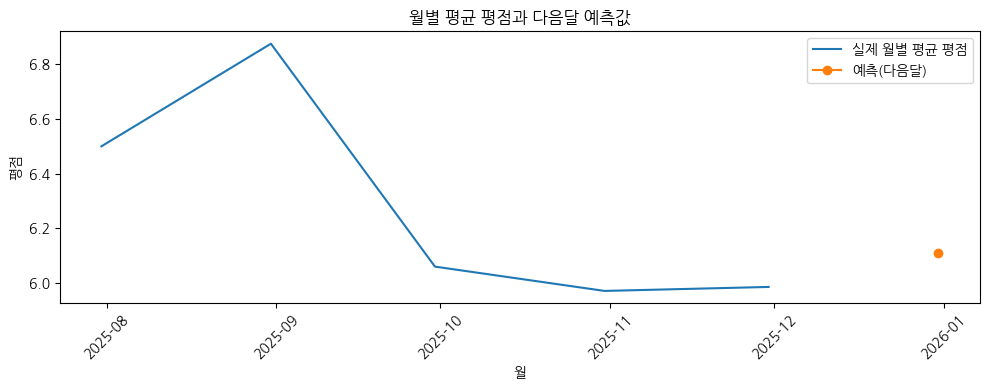

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

from matplotlib import rcParams
rcParams["font.family"] = "NanumGothic"
rcParams["axes.unicode_minus"] = False


df = pd.read_csv("hms_movies_clean.csv")

def extract_date(text):
    if pd.isna(text):
        return pd.NaT
    s = str(text)
    m = re.search(r"\d{4}[.\-]\d{1,2}[.\-]\d{1,2}", s)
    if not m:
        return pd.NaT
    d = m.group(0).replace(".", "-")
    return pd.to_datetime(d, format="%Y-%m-%d", errors="coerce")

df["open_date"] = df["open_date_detail"].apply(extract_date)
df = df.dropna(subset=["open_date"])

rating_col = "cine21_score_detail"
df[rating_col] = pd.to_numeric(df[rating_col], errors="coerce")
df = df.dropna(subset=[rating_col])

monthly = (
    df.set_index("open_date")
      .groupby(pd.Grouper(freq="ME"))[rating_col]
      .mean()
      .sort_index()
)

monthly = monthly.asfreq("ME")
monthly = monthly.interpolate()

model = ARIMA(monthly, order=(1, 1, 1))
fit = model.fit()

forecast_res = fit.get_forecast(steps=1)
pred_mean = forecast_res.predicted_mean

print("최근 5개월 평균 평점")
print(monthly.tail())
print()
print("다음달 예상 평균 평점:", float(pred_mean.iloc[0]))

plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly, label="실제 월별 평균 평점")
plt.plot(pred_mean.index, pred_mean, marker="o", label="예측(다음달)")
plt.xlabel("월")
plt.ylabel("평점")
plt.title("월별 평균 평점과 다음달 예측값")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# [HMS Project Code-11] 주성분(PC1)을 이용한 선형회귀분석

회귀계수(기울기): 0.6156401994034703
절편: 0.5872461331052578
결정계수 R^2: 0.5239960070852112
평균제곱오차 MSE: 0.010928684892342352


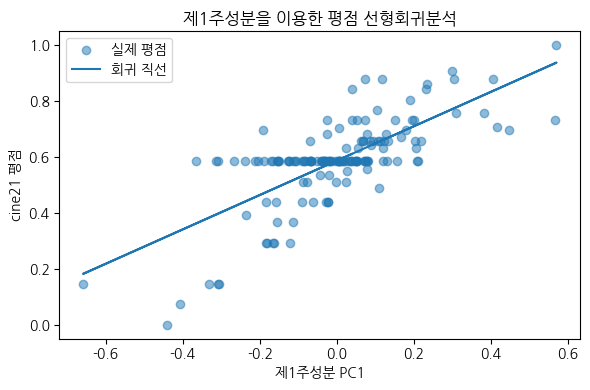

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df_scaled = pd.read_csv("hms_movies_scaled.csv")
df_pca = pd.read_csv("hms_movies_pca.csv")

X = df_pca[["PC1"]]
y = df_scaled["cine21_score_detail"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("회귀계수(기울기):", float(model.coef_[0]))
print("절편:", float(model.intercept_))
print("결정계수 R^2:", r2_score(y, y_pred))
print("평균제곱오차 MSE:", mean_squared_error(y, y_pred))

plt.figure(figsize=(6, 4))
plt.scatter(X["PC1"], y, alpha=0.5, label="실제 평점")
plt.plot(X["PC1"], y_pred, label="회귀 직선")
plt.xlabel("제1주성분 PC1")
plt.ylabel("cine21 평점")
plt.title("제1주성분을 이용한 평점 선형회귀분석")
plt.legend()
plt.tight_layout()
plt.show()


# [HMS Project Code-12] 제1주성분(PC1)을 이용한 영화 평점 예측(선형회귀분석)

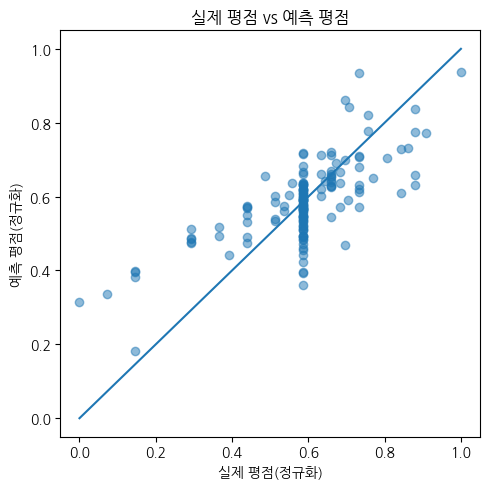

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.figure(figsize=(5, 5))
plt.scatter(y, y_pred, alpha=0.5)
min_v = min(y.min(), y_pred.min())
max_v = max(y.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.xlabel("실제 평점(정규화)")
plt.ylabel("예측 평점(정규화)")
plt.title("실제 평점 vs 예측 평점")
plt.tight_layout()
plt.show()